In [1]:
import pandas as pd
import numpy as np

In [2]:
test='/kaggle/input/datasets/alhiya/skindisease-binary/skin_diseases/test'
train='/kaggle/input/datasets/alhiya/skindisease-binary/skin_diseases/train'
val='/kaggle/input/datasets/alhiya/skindisease-binary/skin_diseases/val'

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as DataLoader
from torchvision import datasets,transforms

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
print(torch.cuda.memory_allocated() / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved() / 1024**2, "MB reserved")

0.0 MB allocated
0.0 MB reserved


In [6]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
from torch.utils.data import DataLoader, random_split,WeightedRandomSampler

In [7]:
import random
from torchvision import datasets, transforms


In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [9]:
train_data=datasets.ImageFolder(root=train)
class_names=train_data.classes
num_classes=len(class_names)
print(class_names)

['regular_skin', 'ringworm']


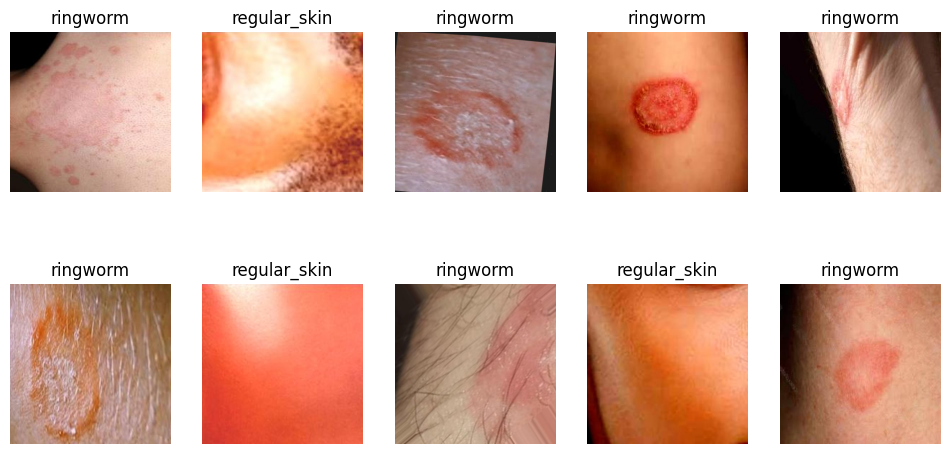

In [10]:
transform=transforms.ToTensor()
train_data = datasets.ImageFolder(root=train, transform=transform)
class_names = train_data.classes
num_classes=len(class_names)
num_images=10
random_indices = random.sample(range(len(train_data)), num_images)
plt.figure(figsize=(12, 6))
for i, idx in enumerate(random_indices):
    image, label = train_data[idx]            # get image and label
    img = image.permute(1, 2, 0)              # convert C,H,W -> H,W,C
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis('off')

plt.show()
    

In [11]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT 

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 204MB/s]  


In [12]:
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = True


# Add dropout to the classification head
pretrained_vit.heads = nn.Sequential(
    nn.Dropout(p=0.5),  # 50% dropout
    nn.Linear(in_features=768, out_features=len(class_names))
).to(device)

In [13]:
train_aug=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3,contrast=0.2),
    transforms.RandomResizedCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    
])

In [14]:
test_transform=transforms.Compose([
transforms.Resize((224,224)),
    transforms.ToTensor()
])
val_dataset=datasets.ImageFolder(
    root=val,
    transform=test_transform
)
test_dataset=datasets.ImageFolder(
    root=test,
    transform=test_transform
)
train_dataset=datasets.ImageFolder(
    root=train,
    transform=train_aug
)

In [15]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32)
test_loader=DataLoader(test_dataset,batch_size=32)


In [16]:
import torch
from torch import nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    pretrained_vit.heads.parameters(),  # train only head
    lr=1e-3,
    weight_decay=1e-4  # no decay for head-only training
)

In [17]:
#train
def training(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [18]:
#validation
def validation(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [19]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [20]:
EPOCHS = 30

for epoch in range(EPOCHS):
    # Training
    train_loss, train_acc = training(pretrained_vit, train_loader, optimizer, criterion, device)
    
    # Validation
    val_loss, val_acc = validation(pretrained_vit, val_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/30
Train Loss: 13.6110, Train Acc: 0.8717
Val Loss: 2.0547, Val Acc: 0.9667
Epoch 2/30
Train Loss: 7.6787, Train Acc: 0.9473
Val Loss: 1.7499, Val Acc: 0.9533
Epoch 3/30
Train Loss: 6.9290, Train Acc: 0.9359
Val Loss: 1.7188, Val Acc: 0.9467
Epoch 4/30
Train Loss: 5.8032, Train Acc: 0.9565
Val Loss: 1.7136, Val Acc: 0.9667
Epoch 5/30
Train Loss: 6.9507, Train Acc: 0.9387
Val Loss: 1.5539, Val Acc: 0.9600
Epoch 6/30
Train Loss: 5.5321, Train Acc: 0.9551
Val Loss: 1.4964, Val Acc: 0.9667
Epoch 7/30
Train Loss: 5.9251, Train Acc: 0.9508
Val Loss: 1.4848, Val Acc: 0.9567
Epoch 8/30
Train Loss: 5.1824, Train Acc: 0.9544
Val Loss: 1.4003, Val Acc: 0.9600
Epoch 9/30
Train Loss: 5.8169, Train Acc: 0.9537
Val Loss: 1.4411, Val Acc: 0.9667
Epoch 10/30
Train Loss: 5.3454, Train Acc: 0.9544
Val Loss: 1.4440, Val Acc: 0.9733
Epoch 11/30
Train Loss: 5.1676, Train Acc: 0.9544
Val Loss: 1.3241, Val Acc: 0.9633
Epoch 12/30
Train Loss: 5.8735, Train Acc: 0.9465
Val Loss: 1.3600, Val Acc: 0.9667


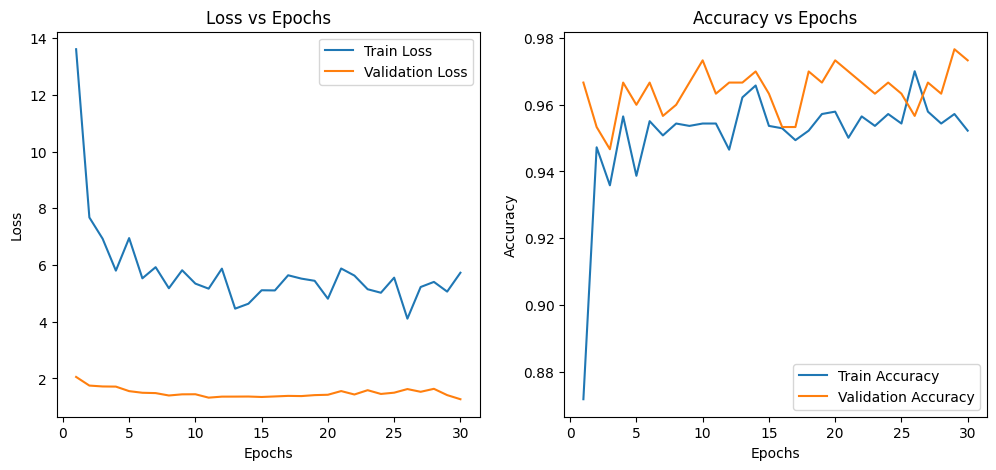

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [25]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [26]:
test_loss, test_acc = Test(
    pretrained_vit, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9637


In [27]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = pretrained_vit(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [28]:
from sklearn.metrics import *
import seaborn as sns

In [29]:
classes = train_dataset.classes

Classification Report:

              precision    recall  f1-score   support

regular_skin       0.94      0.96      0.95       109
    ringworm       0.98      0.96      0.97       194

    accuracy                           0.96       303
   macro avg       0.96      0.96      0.96       303
weighted avg       0.96      0.96      0.96       303



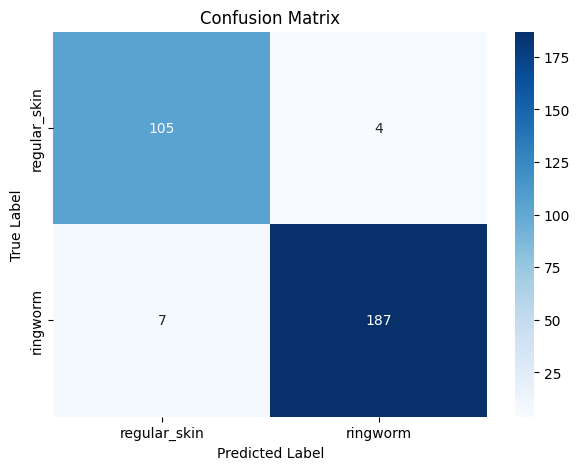

In [30]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [59]:
from torchvision import models

# Load pretrained VGG19
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

In [62]:
# Replace classifier
for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

model = model.to(device)

In [63]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),  # train only classifier
    lr=1e-3,
    weight_decay=1e-4
)

In [64]:
#train
def training(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [65]:
#validation
def validation(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [66]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [67]:
EPOCHS = 50

for epoch in range(EPOCHS):
    # Training
    train_loss, train_acc = training(model, train_loader, optimizer, criterion, device)
    
    # Validation
    val_loss, val_acc = validation(model, val_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/50
Train Loss: 19.7496, Train Acc: 0.8318
Val Loss: 3.7862, Val Acc: 0.8267
Epoch 2/50
Train Loss: 10.4908, Train Acc: 0.9052
Val Loss: 2.1253, Val Acc: 0.9233
Epoch 3/50
Train Loss: 8.9695, Train Acc: 0.9180
Val Loss: 2.3163, Val Acc: 0.9067
Epoch 4/50
Train Loss: 9.4077, Train Acc: 0.9123
Val Loss: 2.3675, Val Acc: 0.9000
Epoch 5/50
Train Loss: 10.4355, Train Acc: 0.9045
Val Loss: 2.4827, Val Acc: 0.8900
Epoch 6/50
Train Loss: 7.8069, Train Acc: 0.9273
Val Loss: 2.2464, Val Acc: 0.9067
Epoch 7/50
Train Loss: 8.5178, Train Acc: 0.9337
Val Loss: 2.0907, Val Acc: 0.9167
Epoch 8/50
Train Loss: 7.5561, Train Acc: 0.9351
Val Loss: 2.7838, Val Acc: 0.8833
Epoch 9/50
Train Loss: 7.5709, Train Acc: 0.9344
Val Loss: 2.4583, Val Acc: 0.8833
Epoch 10/50
Train Loss: 6.8838, Train Acc: 0.9316
Val Loss: 4.0736, Val Acc: 0.8433
Epoch 11/50
Train Loss: 8.2643, Train Acc: 0.9259
Val Loss: 3.2333, Val Acc: 0.8433
Epoch 12/50
Train Loss: 6.7571, Train Acc: 0.9373
Val Loss: 3.0680, Val Acc: 0.870

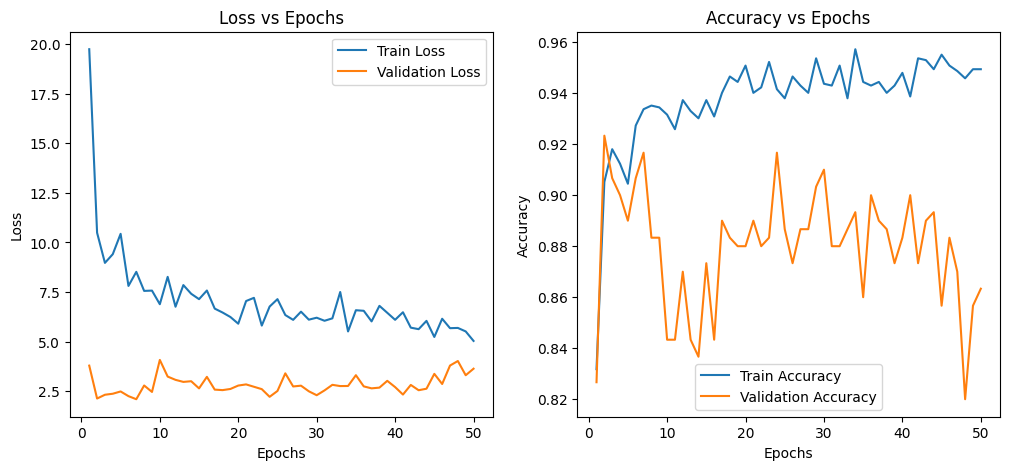

In [68]:
import matplotlib.pyplot as plt
epochs = range(1, EPOCHS + 1)
# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [69]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [70]:
test_loss, test_acc = Test(
    model, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8218


In [79]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [80]:
from sklearn.metrics import *
import seaborn as sns

In [81]:
classes = train_dataset.classes

Classification Report:

              precision    recall  f1-score   support

regular_skin       0.91      0.56      0.69       109
    ringworm       0.80      0.97      0.87       194

    accuracy                           0.82       303
   macro avg       0.85      0.76      0.78       303
weighted avg       0.84      0.82      0.81       303



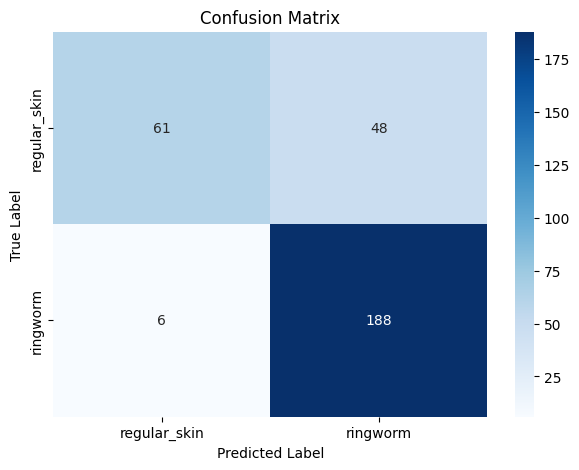

In [82]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [93]:
from torchvision import models

model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

In [94]:


num_features = model.classifier.in_features  # 1024

model.classifier = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

In [95]:
for param in model.features.parameters():
    param.requires_grad = False

In [101]:
optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3,weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

model=model.to(device)

In [102]:
#train
def training(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss, acc
#validation
def validation(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [103]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [104]:
EPOCHS = 50

for epoch in range(EPOCHS):
    # Training
    train_loss, train_acc = training(model, train_loader, optimizer, criterion, device)
    
    # Validation
    val_loss, val_acc = validation(model, val_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/50
Train Loss: 17.6587, Train Acc: 0.8104
Val Loss: 4.9966, Val Acc: 0.6967
Epoch 2/50
Train Loss: 13.7290, Train Acc: 0.8646
Val Loss: 4.1346, Val Acc: 0.7600
Epoch 3/50
Train Loss: 13.3935, Train Acc: 0.8703
Val Loss: 4.0077, Val Acc: 0.7667
Epoch 4/50
Train Loss: 9.3555, Train Acc: 0.9195
Val Loss: 4.2012, Val Acc: 0.7700
Epoch 5/50
Train Loss: 11.2847, Train Acc: 0.8995
Val Loss: 4.6643, Val Acc: 0.7500
Epoch 6/50
Train Loss: 10.5723, Train Acc: 0.9081
Val Loss: 4.3592, Val Acc: 0.7467
Epoch 7/50
Train Loss: 9.4865, Train Acc: 0.9059
Val Loss: 4.5029, Val Acc: 0.7533
Epoch 8/50
Train Loss: 11.1764, Train Acc: 0.8981
Val Loss: 8.4133, Val Acc: 0.6667
Epoch 9/50
Train Loss: 10.1105, Train Acc: 0.9138
Val Loss: 8.2037, Val Acc: 0.6733
Epoch 10/50
Train Loss: 8.8869, Train Acc: 0.9130
Val Loss: 3.3469, Val Acc: 0.8633
Epoch 11/50
Train Loss: 9.9878, Train Acc: 0.9095
Val Loss: 5.4443, Val Acc: 0.7333
Epoch 12/50
Train Loss: 8.8982, Train Acc: 0.9287
Val Loss: 5.5588, Val Acc: 0

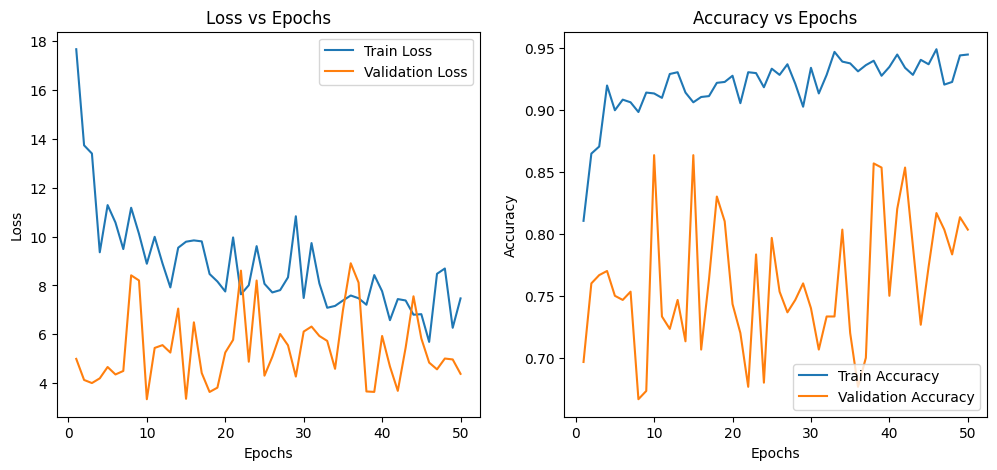

In [105]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [106]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [107]:
test_loss, test_acc = Test(
    model, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7888


In [108]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [109]:
from sklearn.metrics import *
import seaborn as sns
classes = train_dataset.classes

Classification Report:

              precision    recall  f1-score   support

regular_skin       0.92      0.45      0.60       109
    ringworm       0.76      0.98      0.86       194

    accuracy                           0.79       303
   macro avg       0.84      0.71      0.73       303
weighted avg       0.82      0.79      0.77       303



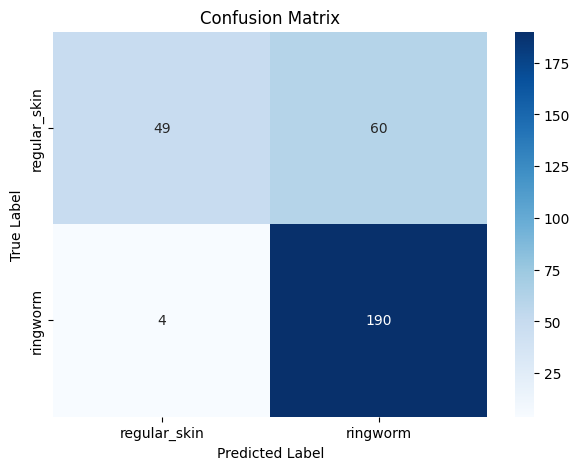

In [110]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [10]:
from torchvision import models

model = models.inception_v3(
    weights=models.Inception_V3_Weights.DEFAULT
)
num_features = model.fc.in_features

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 239MB/s] 


In [11]:
model.aux_logits = False
model.AuxLogits = None

In [12]:
for param in model.parameters():
    param.requires_grad = False

In [13]:
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)
model=model.to(device)

In [14]:
train_aug = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [15]:
test_transform=transforms.Compose([
transforms.Resize((299,299)),
    transforms.ToTensor()
])
val_dataset=datasets.ImageFolder(
    root=val,
    transform=test_transform
)
test_dataset=datasets.ImageFolder(
    root=test,
    transform=test_transform
)
train_dataset=datasets.ImageFolder(
    root=train,
    transform=train_aug
)

In [16]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32)
test_loader=DataLoader(test_dataset,batch_size=32)


In [17]:
optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

In [18]:
#train
def training(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss, acc
#validation
def validation(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [19]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [20]:
EPOCHS = 50

for epoch in range(EPOCHS):
    # Training
    train_loss, train_acc = training(model, train_loader, optimizer, criterion, device)
    
    # Validation
    val_loss, val_acc = validation(model, val_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/50
Train Loss: 19.3904, Train Acc: 0.7790
Val Loss: 4.2219, Val Acc: 0.8400
Epoch 2/50
Train Loss: 14.8359, Train Acc: 0.8589
Val Loss: 3.7702, Val Acc: 0.8233
Epoch 3/50
Train Loss: 12.9358, Train Acc: 0.8653
Val Loss: 4.4743, Val Acc: 0.7733
Epoch 4/50
Train Loss: 12.7423, Train Acc: 0.8774
Val Loss: 3.9858, Val Acc: 0.7933
Epoch 5/50
Train Loss: 12.5938, Train Acc: 0.8795
Val Loss: 3.7694, Val Acc: 0.8267
Epoch 6/50
Train Loss: 14.0848, Train Acc: 0.8553
Val Loss: 3.4825, Val Acc: 0.8467
Epoch 7/50
Train Loss: 13.8876, Train Acc: 0.8525
Val Loss: 3.7084, Val Acc: 0.8067
Epoch 8/50
Train Loss: 12.1051, Train Acc: 0.8817
Val Loss: 3.5547, Val Acc: 0.8233
Epoch 9/50
Train Loss: 14.1624, Train Acc: 0.8582
Val Loss: 3.2463, Val Acc: 0.8567
Epoch 10/50
Train Loss: 11.8303, Train Acc: 0.8909
Val Loss: 4.7516, Val Acc: 0.8000
Epoch 11/50
Train Loss: 11.8295, Train Acc: 0.8860
Val Loss: 3.3271, Val Acc: 0.8500
Epoch 12/50
Train Loss: 11.5395, Train Acc: 0.8945
Val Loss: 3.4272, Val A

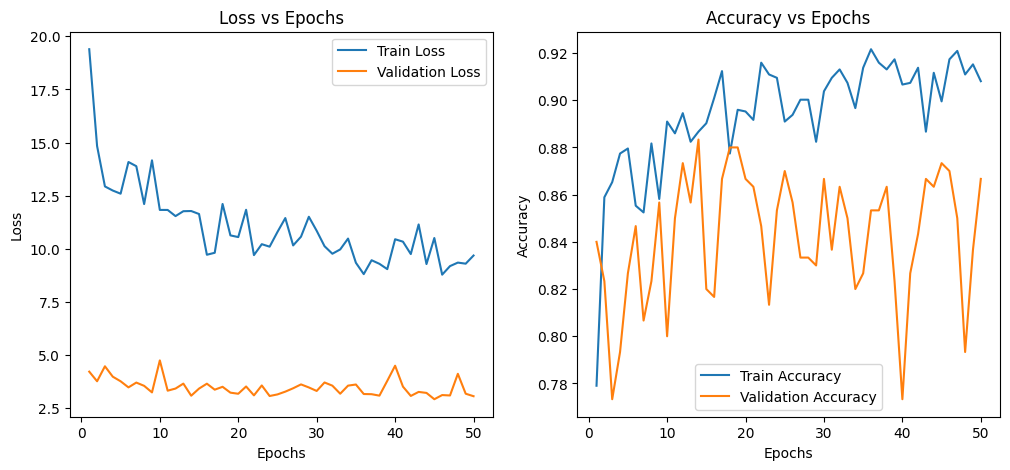

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [22]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [23]:
test_loss, test_acc = Test(
    model, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8713


In [24]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [25]:
from sklearn.metrics import *
import seaborn as sns
classes = train_dataset.classes

Classification Report:

              precision    recall  f1-score   support

regular_skin       0.90      0.72      0.80       109
    ringworm       0.86      0.95      0.90       194

    accuracy                           0.87       303
   macro avg       0.88      0.84      0.85       303
weighted avg       0.87      0.87      0.87       303



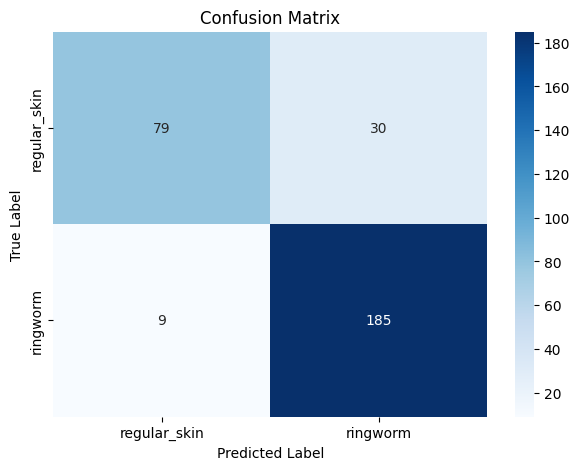

In [26]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()

In [37]:
import timm

model = timm.create_model(
    'inception_resnet_v2',
    pretrained=True,
    num_classes=num_classes
)

In [38]:
in_features = model.get_classifier().in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)
model=model.to(device)

In [44]:
for param in model.parameters():
    param.requires_grad = False
for param in model.get_classifier().parameters():
    param.requires_grad = True

In [45]:
optimizer = torch.optim.AdamW(
    model.get_classifier().parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

In [46]:
#train
def training(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return total_loss, acc
#validation
def validation(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [47]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [48]:
EPOCHS = 50
for epoch in range(EPOCHS):
    # Training
    train_loss, train_acc = training(model, train_loader, optimizer, criterion, device)
    
    # Validation
    val_loss, val_acc = validation(model, val_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/50
Train Loss: 25.0489, Train Acc: 0.7106
Val Loss: 5.9040, Val Acc: 0.6833
Epoch 2/50
Train Loss: 19.0728, Train Acc: 0.8232
Val Loss: 5.6888, Val Acc: 0.7133
Epoch 3/50
Train Loss: 16.6755, Train Acc: 0.8496
Val Loss: 5.6424, Val Acc: 0.6733
Epoch 4/50
Train Loss: 14.3762, Train Acc: 0.8817
Val Loss: 5.5369, Val Acc: 0.7067
Epoch 5/50
Train Loss: 13.8596, Train Acc: 0.8888
Val Loss: 5.5436, Val Acc: 0.7167
Epoch 6/50
Train Loss: 13.0025, Train Acc: 0.8967
Val Loss: 5.8804, Val Acc: 0.6967
Epoch 7/50
Train Loss: 12.3404, Train Acc: 0.9031
Val Loss: 5.3769, Val Acc: 0.7067
Epoch 8/50
Train Loss: 11.8737, Train Acc: 0.9095
Val Loss: 5.6581, Val Acc: 0.6933
Epoch 9/50
Train Loss: 12.8870, Train Acc: 0.8788
Val Loss: 5.0782, Val Acc: 0.7300
Epoch 10/50
Train Loss: 11.6007, Train Acc: 0.8974
Val Loss: 5.6554, Val Acc: 0.7233
Epoch 11/50
Train Loss: 11.7654, Train Acc: 0.8952
Val Loss: 4.9054, Val Acc: 0.7767
Epoch 12/50
Train Loss: 10.6714, Train Acc: 0.9088
Val Loss: 4.7463, Val A

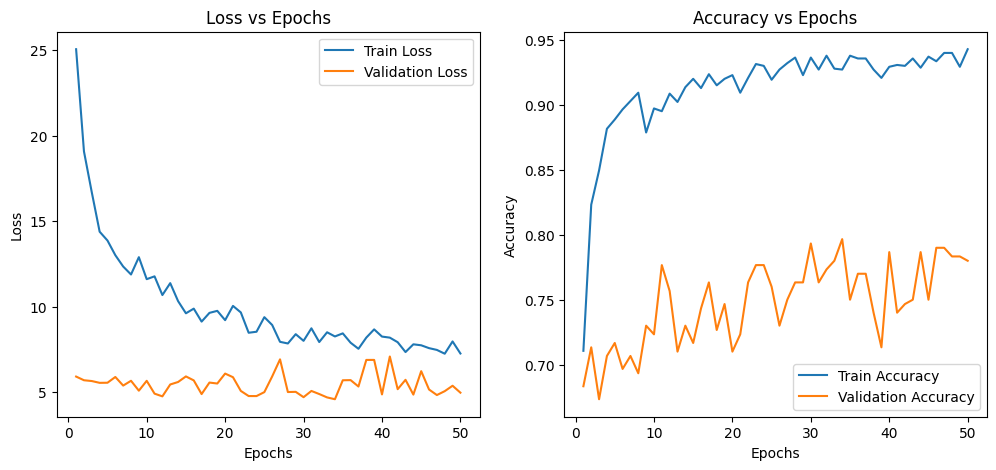

In [49]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.show()

In [50]:
#test
def Test(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return total_loss, acc

In [51]:
test_loss, test_acc = Test(
    model, test_loader, criterion, device
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7591


In [52]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [53]:
from sklearn.metrics import *
import seaborn as sns
classes = train_dataset.classes

Classification Report:

              precision    recall  f1-score   support

regular_skin       0.95      0.35      0.51       109
    ringworm       0.73      0.99      0.84       194

    accuracy                           0.76       303
   macro avg       0.84      0.67      0.68       303
weighted avg       0.81      0.76      0.72       303



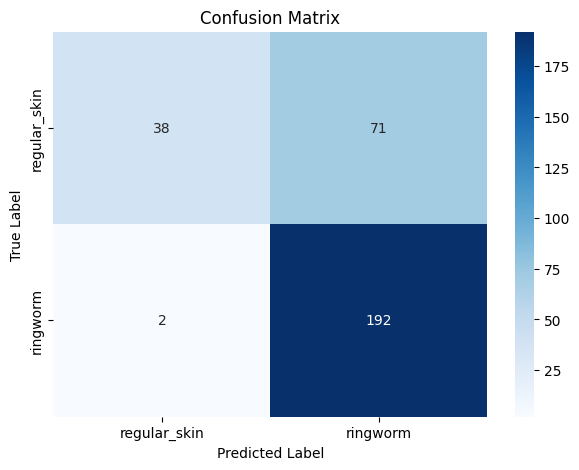

In [54]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))

# -------------------
# Confusion Matrix
# -------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.show()